<a href="https://colab.research.google.com/github/chindyarmy/Analisis-Deret-Waktu/blob/main/TP2_Kecenderungan_dalam_Deret_Waktu_Chindy_Putri_Army.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : Chindy Putri Army

NIM : M0501251024

# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilaitengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [5]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1024)
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 12
beta0 = 34
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})


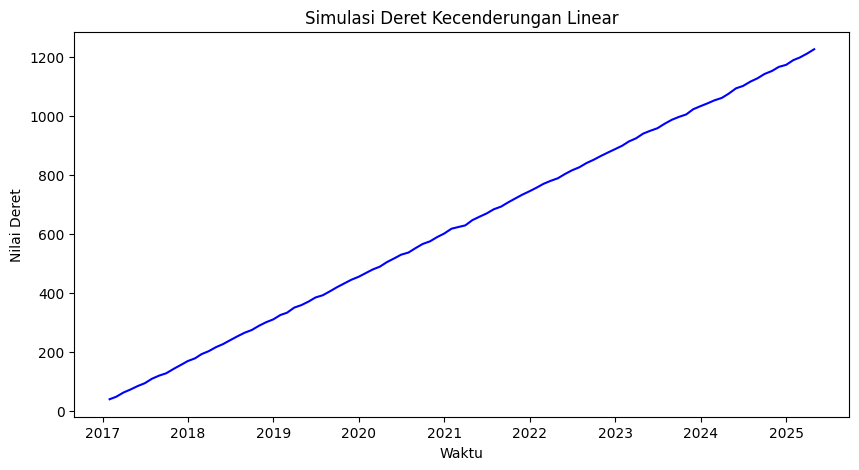

In [6]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

**Cek apakah ada korelasi antar pengamatan?**

Berdasarkan plot deret waktu terlihat bahwa pola cenderung linear dan meningkat secara konsisten dari tahun 2017 hingga 2025. Nilai pengamatan mengalami peningkatan seiring bertambahnya waktu. Tidak tampak adanya fluktuasi musiman, siklus, maupun outlier yang signifikan. Seluruh variasi dalam data didominasi oleh komponen tren sehingga menunjukkan adanya tren positif yang kuat dalam deret. Kondisi ini mengindikasikan bahwa deret bersifat non-stasioner dan terdapat indikasi korelasi positif antar pengamatan, sehingga asumsi independensi antar data belum terpenuhi


In [7]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 1.0000


In [8]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.717e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.59e-219
Time:                        12:29:43   Log-Likelihood:                -215.14
No. Observations:                 100   AIC:                             434.3
Df Residuals:                      98   BIC:                             439.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           34.2446      0.417     82.092   

**Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli?**

Hasil pengepasan model regresi menghasilkan nilai intercept sebesar 34,2446 dan koefisien tren sebesar 12,0004. Nilai tersebut sangat mendekati parameter asli yang digunakan dalam simulasi, yaitu β₀ = 34 dan β₁ = 12. Selisih antara nilai estimasi dan parameter asli relatif kecil. Hal ini menunjukkan bahwa model regresi mampu mengestimasi parameter yang digunakan dalam pembentukan data dengan sangat baik.

**Apakah model regresi yang dipaskan sudah bagus?**
Model regresi yang dipaskan sangat baik dalam menggambarkan pola data. Hal ini ditunjukkan oleh nilai R-squared sebesar 1,000, yang berarti hampir seluruh variasi nilai pengamatan dapat dijelaskan oleh variabel waktu. Koefisien tren juga signifikan secara statistik dengan p-value < 0,001. Nilai Durbin-Watson sebesar 1,736 menunjukkan adanya kemungkinan korelasi positif yang lemah pada residual. Selain itu, berdasarkan Prob(JB) = 0,00717, residual belum memenuhi asumsi normalitas pada taraf 5%. Dengan demikian, model sudah sangat baik dalam menangkap tren linear, meskipun masih terdapat beberapa hal yang perlu diperhatikan pada asumsi residual.

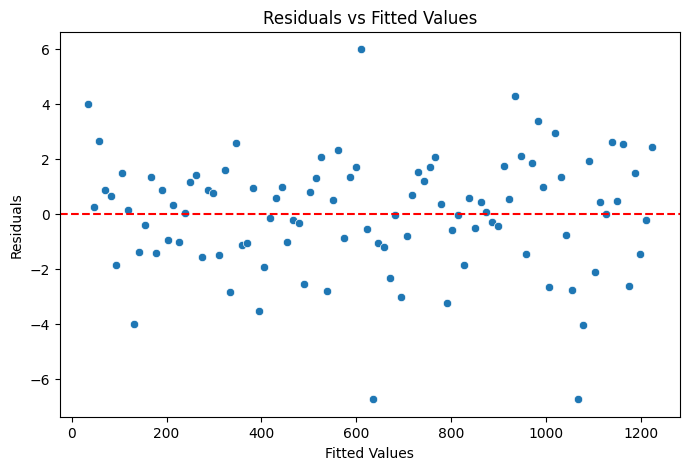

In [9]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


**Apa interpretasi dari plot tersebut?**

Berdasarkan plot tersebut terlihat bahwa titik residual tersebar di sekitar garis nol dan tidak membentuk pola tertentu. Residual berada pada sisi positif dan negatif dengan penyebaran yang relatif merata sepanjang nilai fitted. Hal ini menunjukkan bahwa tidak terdapat pola sistematis yang kuat pada residual. Penyebaran residual juga relatif konstan sehingga tidak terlihat adanya indikasi heteroskedastisitas yang jelas. Namun terdapat beberapa residual yang cukup jauh dari garis nol sehingga perlu diperhatikan lebih lanjut. Secara keseluruhan model telah mampu menangkap pola linear pada data dengan cukup baik.

In [10]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.2396


**Apa kesimpulan dari nilai uji Breusch Pagan tersebut?**

Berdasarkan hasil uji Breusch-Pagan diperoleh nilai p-value sebesar 0.2396. Nilai tersebut lebih besar dari taraf signifikansi 5%. Maka H0 tidak ditolak sehingga tidak terbukti adanya heteroskedastisitas pada residual. Hal ini menunjukkan bahwa varians residual cenderung konstan dan asumsi homoskedastisitas pada model regresi terpenuhi.

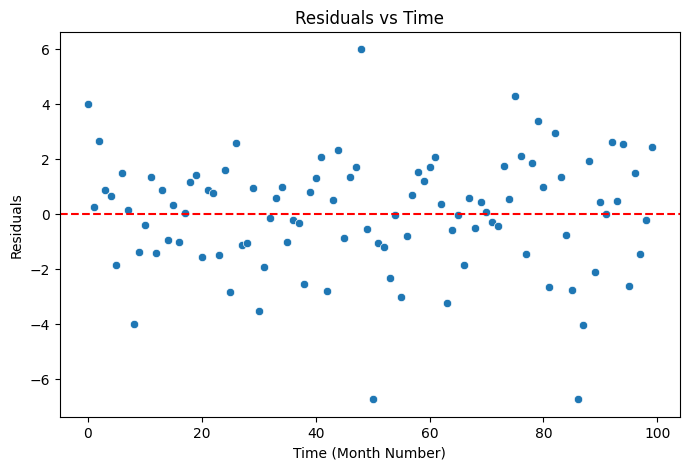

In [11]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


Berdasarkan plot Residuals vs Time terlihat bahwa residual tersebar di sekitar garis nol sepanjang periode pengamatan. Tidak terlihat adanya pola tertentu seperti tren maupun pola musiman pada residual. Residual juga tersebar pada sisi positif dan negatif sehingga tidak menunjukkan adanya penyimpangan sistematis terhadap waktu. Meskipun terdapat beberapa residual yang cukup jauh dari garis nol, secara keseluruhan residual menunjukkan pola yang relatif acak. Hal ini menunjukkan bahwa model telah mampu menangkap pola tren pada data dengan baik.

<Figure size 800x500 with 0 Axes>

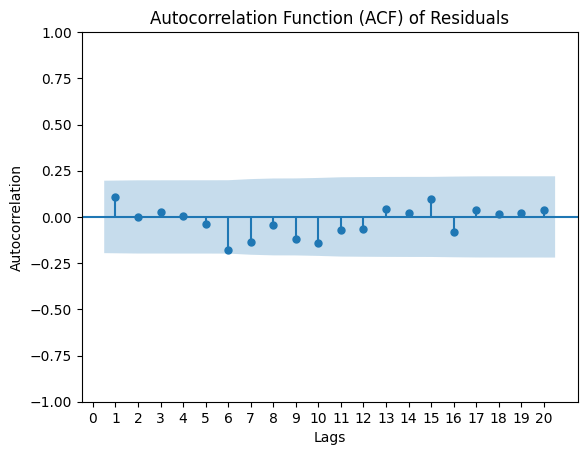

In [12]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


**Apa yang dapat Anda simpulkan dari plot di atas?**

Berdasarkan plot Autocorrelation Function (ACF) residual terlihat bahwa nilai autokorelasi pada lag 1 hingga 20 berada dalam batas interval kepercayaan. Tidak terdapat batang ACF yang melewati batas tersebut sehingga tidak terdapat autokorelasi yang signifikan pada residual. Hal ini menunjukkan bahwa residual tidak memiliki pola ketergantungan yang kuat antar waktu. Dengan demikian asumsi independensi residual dapat dianggap terpenuhi.

In [13]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    1.170158   0.279369
2    1.170524   0.556960
3    1.232870   0.745132
4    1.234769   0.872342
5    1.370837   0.927477
6    4.852764   0.562831
7    6.827900   0.447016
8    7.047091   0.531561
9    8.623202   0.472757
10  10.886862   0.366400
11  11.505092   0.401968
12  11.963540   0.448612
13  12.196142   0.511630
14  12.251476   0.586115
15  13.366779   0.573991
16  14.181432   0.585200
17  14.360290   0.641455
18  14.401857   0.702544
19  14.451602   0.756758


**Apa kesimpulan dari hasil uji Ljung-Box tersebut?**

Berdasarkan hasil uji Ljung-Box terlihat bahwa nilai p-value pada lag 1 hingga 19 seluruhnya lebih besar dari 0,05. Hal tersebut menunjukkan bahwa tidak terdapat autokorelasi yang signifikan pada residual. H0 tidak ditolak sehingga residual tidak menunjukkan adanya ketergantungan antar waktu. Oleh karena itu asumsi independensi antar data dapat dianggap terpenuhi.

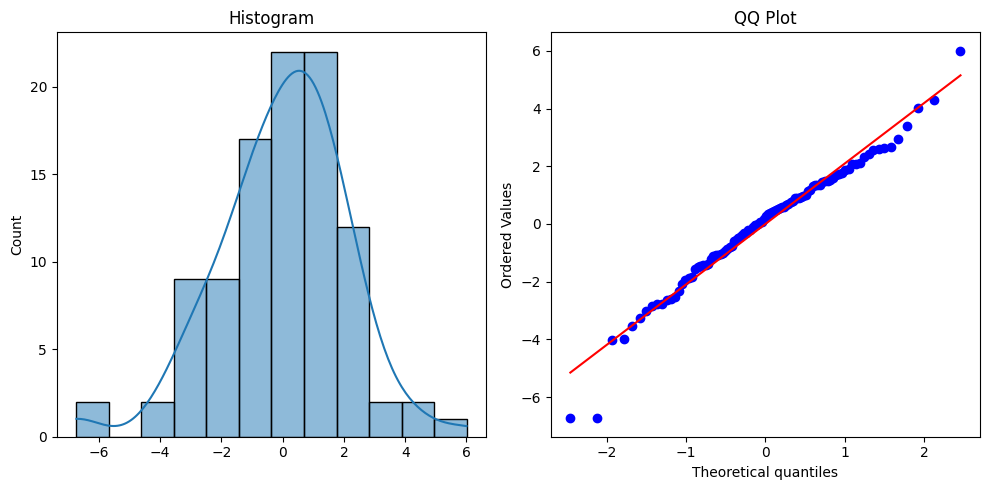

In [14]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

**Apa kesimpulan Anda berdasarkan plot di atas?**

Berdasarkan histogram terlihat bahwa residual memiliki pola yang relatif menyerupai distribusi normal dan sebagian besar nilai residual berada di sekitar nol. Pada QQ Plot sebagian besar titik berada di sekitar garis diagonal. Namun terdapat beberapa titik pada bagian ekor yang menyimpang dari garis diagonal. Hal ini menunjukkan bahwa residual secara umum mendekati distribusi normal meskipun terdapat sedikit penyimpangan pada bagian ekor. Dengan demikian asumsi normalitas residual dapat dianggap cukup terpenuhi.

In [15]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9762040933377164, p-value = 0.0670485134260063


**Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?**

Berdasarkan hasil uji Shapiro-Wilk diperoleh p-value sebesar 0,0670. Nilai tersebut lebih besar dari 0,05 sehingga H0 tidak ditolak dan residual dapat dikatakan berdistribusi normal. Kesimpulan ini sama dengan hasil plot yang menunjukkan bahwa residual secara umum mengikuti pola distribusi normal. Dengan demikian, asumsi normalitas residual terpenuhi.

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [16]:
# Menentukan parameter simulasi
np.random.seed(1024)
n_periods = 120
beta_0, beta_1, beta_2= 74, 12, 0.48
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

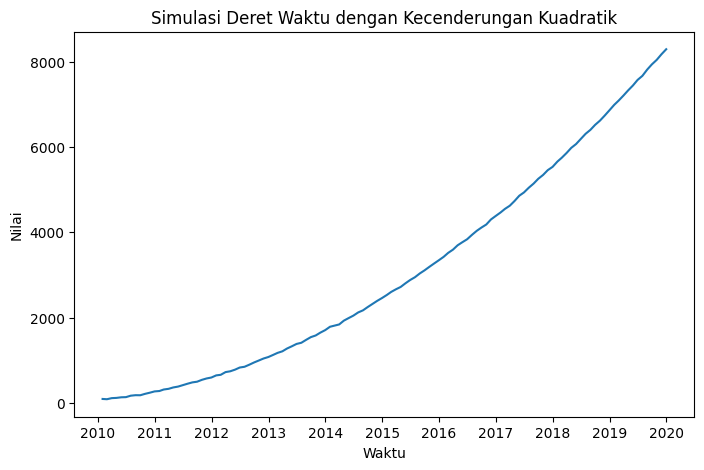

In [17]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

**Apa interpretasi Anda terhadap deret? Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear?**

Berdasarkan plot deret waktu dapat dilihat bahwa nilai pengamatan terus meningkat dari tahun 2010 sampai 2020. Kenaikan nilai tersebut tidak konstan karena semakin bertambahnya waktu nilai pengamatan meningkat semakin cepat. Pola tersebut membentuk kurva yang melengkung ke atas sehingga menunjukkan adanya kecenderungan kuadratik. Berbeda dengan pola linear yang meningkat secara relatif konstan, pola kuadratik memiliki kenaikan yang semakin besar dari waktu ke waktu.

In [18]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.411e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.61e-279
Time:                        12:29:44   Log-Likelihood:                -448.31
No. Observations:                 120   AIC:                             902.6
Df Residuals:                     117   BIC:                             911.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         76.2875      2.767     27.567      0.0

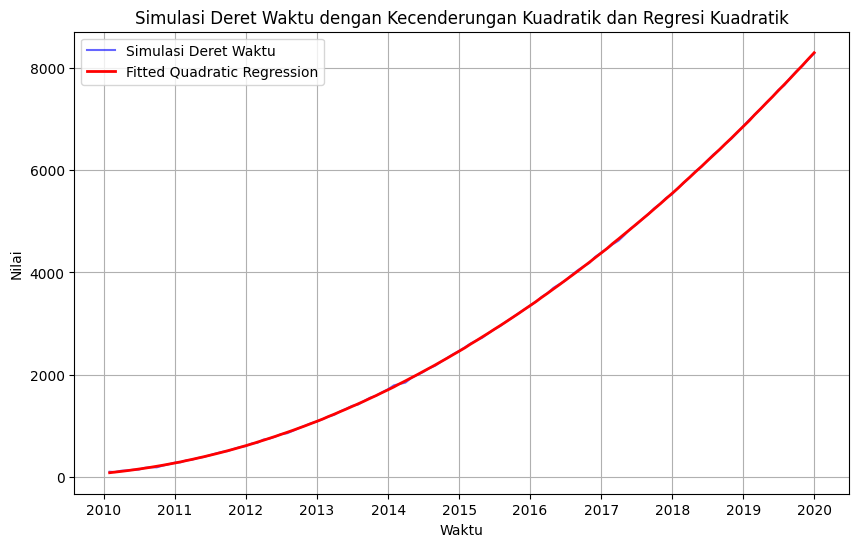

In [19]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

**Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!**

Berdasarkan hasil pengujian, model regresi kuadratik sudah memenuhi asumsi-asumsi model. Uji Breusch-Pagan menghasilkan p-value sebesar 0,5280 > 0,05, sehingga tidak terdapat masalah heteroskedastisitas. Uji Ljung-Box menunjukkan seluruh p-value pada lag 1–5 lebih besar dari 0,05, sehingga tidak terdapat autokorelasi pada residual. Selain itu, uji Shapiro-Wilk menghasilkan p-value sebesar 0,1071 > 0,05, sehingga residual dapat dianggap berdistribusi normal. Dengan demikian, asumsi homoskedastisitas, independensi, dan normalitas residual terpenuhi.


**Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!**

Model regresi kuadratik yang dipaskan sudah tepat untuk menggambarkan deret. Nilai R-squared sebesar 1,000 menunjukkan bahwa model mampu menjelaskan hampir seluruh variasi pada data. Pada grafik, garis hasil regresi kuadratik terlihat hampir berhimpit dengan pola deret. Selain itu, koefisien x1 dan x2 signifikan dengan p-value sebesar 0,000. Model kuadratik juga sesuai dengan pola data yang menunjukkan kenaikan semakin cepat seiring bertambahnya waktu. Dengan demikian, model regresi kuadratik sudah tepat dalam menggambarkan pola deret tersebut.

In [20]:
# cek asumsi model regresi kuadratik
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

print("\n=== HASIL UJI ASUMSI MODEL REGRESI KUADRATIK ===")

# 1. Uji Breusch-Pagan (Homoskedastisitas)
bp_test = het_breuschpagan(model_quad.resid, model_quad.model.exog)
print(f"\n1. P-value Breusch-Pagan Test: {bp_test[1]:.4f}")

# 2. Uji Ljung-Box (Autokorelasi)
ljung_box_test = acorr_ljungbox(model_quad.resid, lags=range(1,20), return_df=True)
print("\n2. Ljung-Box Test (5 lag pertama):")
print(ljung_box_test.head()) # Menampilkan 5 lag pertama agar ringkas

# 3. Uji Shapiro-Wilk (Normalitas)
shapiro_stat, shapiro_p_value = stats.shapiro(model_quad.resid)
print(f"\n3. Shapiro-Wilk Test: Statistics = {shapiro_stat:.4f}, p-value = {shapiro_p_value:.4f}")


=== HASIL UJI ASUMSI MODEL REGRESI KUADRATIK ===

1. P-value Breusch-Pagan Test: 0.5280

2. Ljung-Box Test (5 lag pertama):
    lb_stat  lb_pvalue
1  0.689946   0.406183
2  0.753697   0.686020
3  0.807852   0.847588
4  0.904251   0.923950
5  0.904276   0.969911

3. Shapiro-Wilk Test: Statistics = 0.9819, p-value = 0.1071


Dari ketiga pengujian tersebut, asumsi model regresi kuadratik sudah terpenuhi. Residual tidak menunjukkan masalah heteroskedastisitas, tidak terdapat autokorelasi sampai lag ke-5, dan residual berdistribusi normal. Jadi, model regresi kuadratik yang digunakan sudah cukup baik dari sisi asumsi model.

## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [21]:
# Menentukan parameter simulasi
np.random.seed(1024)
n_periods = 120
beta0, beta1, beta2=74,-600, -48
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


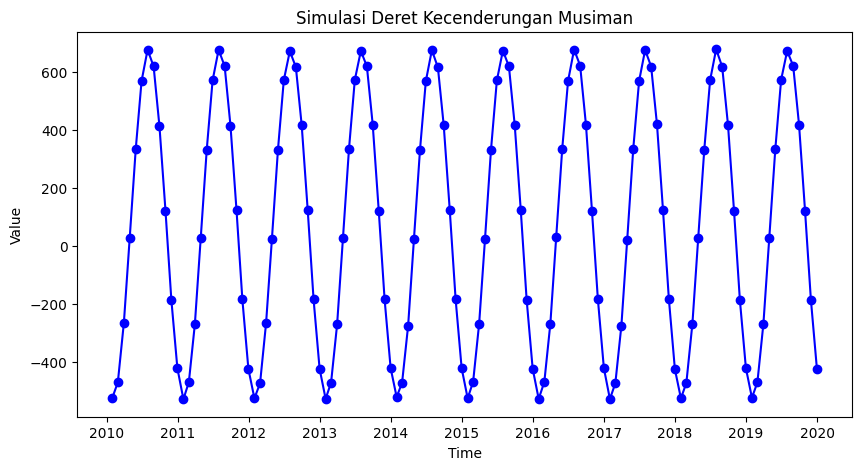

In [22]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


**Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?**

Berdasarkan plot terlihat bahwa nilai pengamatan mengalami pola naik dan turun yang berulang dari tahun 2010 sampai 2020. Pola tersebut berulang setiap 12 periode sehingga menunjukkan adanya pola musiman dengan periode 12. Nilai pengamatan cenderung mencapai nilai tinggi dan rendah pada periode yang sama setiap tahunnya. Dengan demikian, deret tersebut memiliki pola musiman yang cukup jelas.

In [23]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [24]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [25]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [26]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.754e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.52e-247
Time:                        12:29:44   Log-Likelihood:                -249.41
No. Observations:                 120   AIC:                             522.8
Df Residuals:                     108   BIC:                             556.3
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari     -524.1719      0.645   -813.212      0.0

**Bagaimana interpretasi dari hasil tersebut?**

Berdasarkan hasil regresi diperoleh nilai R-squared sebesar 1,000. Hal ini menunjukkan bahwa model mampu menjelaskan hampir seluruh variasi nilai pada deret. Nilai p-value pada uji F sebesar 1,52 × 10⁻²⁴⁷ < 0,05, sehingga model secara keseluruhan signifikan. Dari hasil estimasi terlihat bahwa setiap bulan memiliki nilai koefisien yang berbeda. Koefisien tertinggi terdapat pada bulan Juli sebesar 673,9859, sedangkan koefisien terendah terdapat pada bulan Januari sebesar -524,1719. Perbedaan koefisien antarbulan menunjukkan adanya pola musiman dalam deret. Seluruh koefisien bulan memiliki p-value sebesar 0,000, sehingga perbedaan antarbulan tersebut signifikan secara statistik. Model regresi yang digunakan mampu menggambarkan pola musiman pada deret dengan sangat baik, yang terlihat dari nilai R-squared sebesar 1,000 dan signifikansi seluruh koefisien bulan.

In [27]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

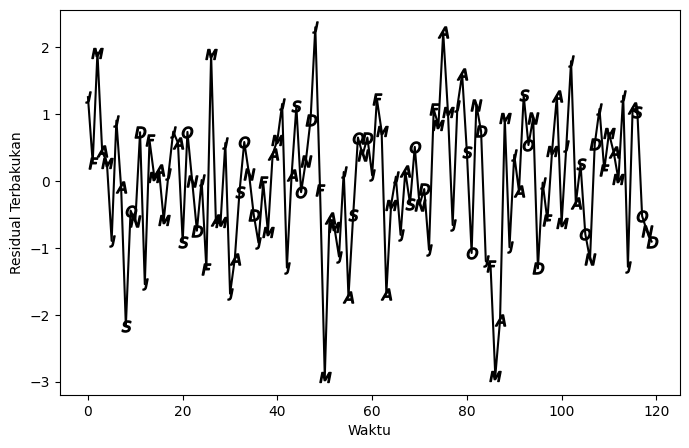

In [28]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


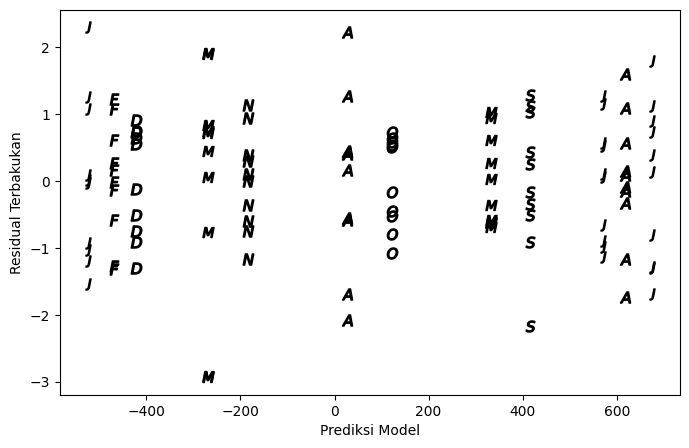

In [29]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

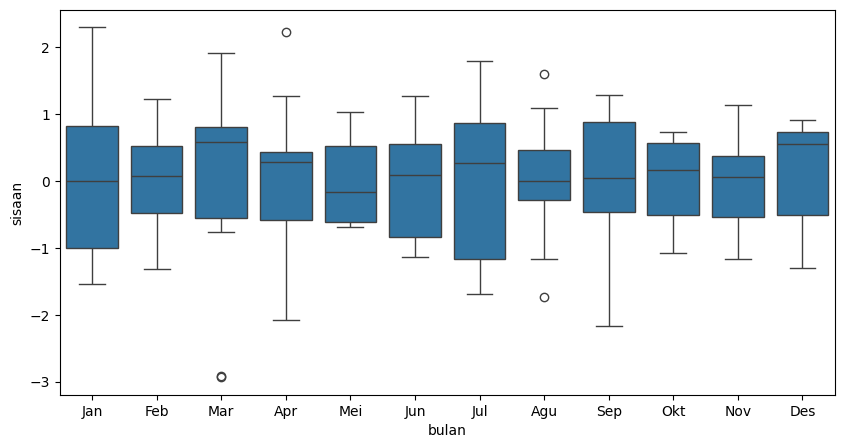

In [30]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

**Bagaimana interpretasi Anda terhadap tiga plot di atas?**

1. Plot residual terhadap waktu

Berdasarkan plot dapat dilihat bahwa residual berfluktuasi di sekitar nilai 0 sepanjang waktu. Tidak terlihat adanya pola naik atau turun yang jelas. Residual juga tersebar pada sisi positif dan negatif dengan penyebaran yang relatif seragam, meskipun terdapat beberapa nilai residual yang cukup jauh dari 0. Tidak terlihat adanya pola sistematis terhadap waktu.

2. Plot residual terhadap prediksi model

Berdasarkan plot dapat dilihat bahwa residual tersebar di sekitar nilai 0 pada berbagai nilai prediksi model. Tidak terlihat pola tertentu atau pola yang semakin melebar. Hal ini menunjukkan bahwa tidak terdapat pola sistematis yang jelas antara residual dan nilai prediksi model.

3. Boxplot residual berdasarkan bulan

berdasarkan plot dapat dilihat bahwa residual pada setiap bulan umumnya tersebar di sekitar nilai 0, meskipun tingkat penyebarannya berbeda antarbulan. Beberapa bulan memiliki penyebaran residual yang lebih besar, seperti Januari dan Juli. Terdapat pula beberapa nilai pencilan, terutama pada Maret, April, dan Agustus. Secara umum, residual pada setiap bulan masih berada di sekitar nilai 0 dan tidak menunjukkan pola yang sangat berbeda antarbulan.

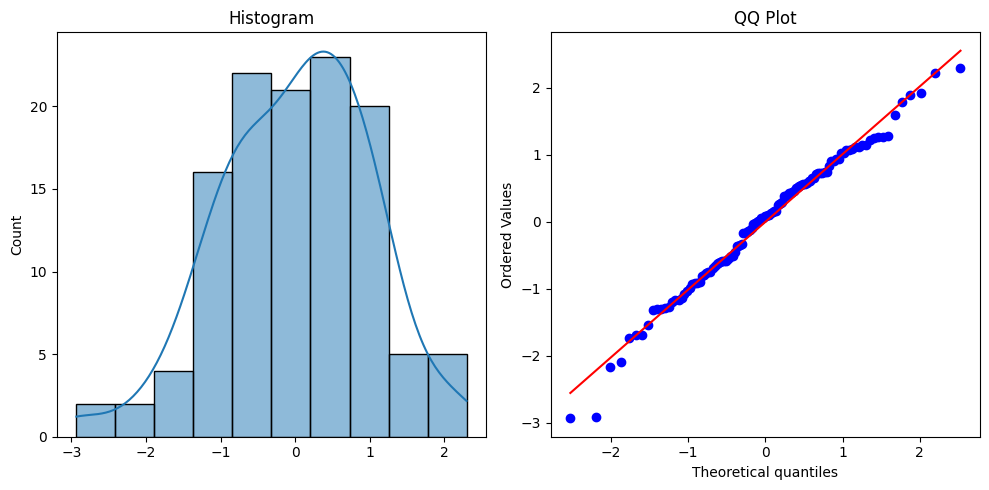

In [31]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

**Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?**

Berdasarkan histogram, residual terlihat cukup menyerupai distribusi normal dengan sebagian besar nilai berada di sekitar 0. Pada QQ plot, sebagian besar titik berada di sekitar garis diagonal, meskipun terdapat beberapa penyimpangan pada bagian ekor. Hal ini menunjukkan bahwa residual secara umum mendekati distribusi normal. Dengan demikian, dari sisi asumsi normalitas residual, model dapat dikatakan cukup baik, meskipun terdapat sedikit penyimpangan pada bagian ekor.

**Hitunglah statistik uji untuk mengecek asumsi model**

In [32]:
# hitung statistik uji untuk mengecek asumsi model tanpa intersep
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

# Uji Breusch-Pagan
# Tambahkan konstanta ke eksogen model sebelum menjalankan uji Breusch-Pagan
bp_test = het_breuschpagan(musiman.resid, sm.add_constant(musiman.model.exog))

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")

P-value Breusch-Pagan Test: 0.0405


In [33]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(musiman.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)

Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    1.242358   0.265017
2    1.242512   0.537269
3    1.420085   0.700834
4    1.430395   0.838895
5    1.432469   0.920729
6    5.218481   0.516112
7    8.197488   0.315502
8    8.203540   0.413845
9    9.169469   0.421780
10  11.881339   0.293077
11  12.335436   0.338965
12  16.048215   0.189038
13  16.144123   0.241435
14  18.040105   0.204960
15  18.416290   0.241413
16  19.479741   0.244572
17  19.624515   0.293884
18  19.632932   0.353860
19  21.491946   0.310265


In [34]:
from scipy import stats

# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(musiman.resid)

print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9871728089760732, p-value = 0.3185828634668032


Berdasarkan ketiga pengujian tersebut, residual telah memenuhi asumsi normalitas dan independensi karena residual berdistribusi normal dan tidak terdapat autokorelasi. Namun, asumsi homoskedastisitas belum terpenuhi karena hasil uji Breusch-Pagan menunjukkan adanya heteroskedastisitas.

In [35]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [36]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.754e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.52e-247
Time:                        12:29:46   Log-Likelihood:                -249.41
No. Observations:                 120   AIC:                             522.8
Df Residuals:                     108   BIC:                             556.3
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -524.1719      0.645   -813.212      0.0

**Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh!**

Pada model dengan intersep, nilai intersep sebesar -524,1719 menunjukkan rata-rata nilai pada bulan Januari sebagai kategori acuan. Koefisien bulan lainnya menunjukkan perbedaan rata-rata nilai bulan tersebut terhadap Januari. Misalnya, koefisien Februari sebesar 54,5327 berarti nilai Februari rata-rata 54,5327 lebih tinggi dibandingkan Januari, sedangkan koefisien Juli sebesar 1198,1578 berarti nilai Juli rata-rata 1198,1578 lebih tinggi dibandingkan Januari. Sementara itu, pada model tanpa intersep, setiap koefisien bulan langsung menunjukkan rata-rata nilai pada bulan tersebut sehingga tidak ada bulan yang menjadi kategori pembanding. Dengan demikian, perbedaan utama kedua model terletak pada cara interpretasi koefisien, sedangkan nilai fitted yang dihasilkan dapat menggambarkan pola musiman yang sama.

**Apakah model dengan intersep sudah memenuhi asumsi regresi?**

Berdasarkan hasil pengujian, residual pada model dengan intersep telah memenuhi asumsi normalitas dan independensi. Hal ini ditunjukkan oleh nilai Prob(Omnibus) = 0,268 dan Prob(Jarque-Bera) = 0,330 yang lebih besar dari 0,05, sehingga residual dapat dianggap berdistribusi normal. Nilai Durbin-Watson = 1,779 juga menunjukkan tidak adanya masalah autokorelasi yang kuat. Namun, berdasarkan uji Breusch-Pagan diperoleh p-value 0,0405, yang lebih kecil dari 0,05, sehingga terdapat heteroskedastisitas. Dengan demikian, model dengan intersep belum sepenuhnya memenuhi asumsi regresi karena asumsi homoskedastisitas belum terpenuhi.

In [37]:
# uji asumsi model dengan intersep
# Uji Breusch-Pagan
bp_test = het_breuschpagan(
    musiman_int.resid,
    musiman_int.model.exog
)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")

# Uji Ljung-Box
ljung_box_test = acorr_ljungbox(
    musiman_int.resid,
    lags=range(1,20),
    return_df=True
)

print("Ljung-Box Test p-value:")
print(ljung_box_test)

# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(musiman_int.resid)

print(
    f"Shapiro-Wilk Test: Statistics = {shapiro_stat:.4f}, "
    f"p-value = {shapiro_p_value:.4f}"
)

P-value Breusch-Pagan Test: 0.0264
Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    1.242358   0.265017
2    1.242512   0.537269
3    1.420085   0.700834
4    1.430395   0.838895
5    1.432469   0.920729
6    5.218481   0.516112
7    8.197488   0.315502
8    8.203540   0.413845
9    9.169469   0.421780
10  11.881339   0.293077
11  12.335436   0.338965
12  16.048215   0.189038
13  16.144123   0.241435
14  18.040105   0.204960
15  18.416290   0.241413
16  19.479741   0.244572
17  19.624515   0.293884
18  19.632932   0.353860
19  21.491946   0.310265
Shapiro-Wilk Test: Statistics = 0.9872, p-value = 0.3186


1. Uji Breusch-Pagan

Berdasarkan hasil uji Breusch-Pagan diperoleh p-value sebesar 0,0264. Nilai tersebut lebih kecil dari taraf signifikansi 5%, sehingga H₀ ditolak. Hal ini menunjukkan bahwa terdapat heteroskedastisitas pada residual, sehingga asumsi homoskedastisitas belum terpenuhi.

2. Uji Ljung-Box

Berdasarkan hasil uji Ljung-Box, seluruh p-value pada lag yang diuji lebih besar dari 0,05. Dengan demikian, H₀ tidak ditolak sehingga tidak terdapat autokorelasi pada residual. Hal ini menunjukkan bahwa asumsi independensi residual terpenuhi.

3. Uji Shapiro-Wilk

Berdasarkan hasil uji Shapiro-Wilk diperoleh p-value sebesar 0,3186. Nilai tersebut lebih besar dari 0,05, sehingga H₀ tidak ditolak. Hal ini menunjukkan bahwa residual dapat dianggap berdistribusi normal, sehingga asumsi normalitas residual terpenuhi.

## Kecenderungan Linear dan Musiman

In [38]:
# Parameter
np.random.seed(1024)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 12, 240 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


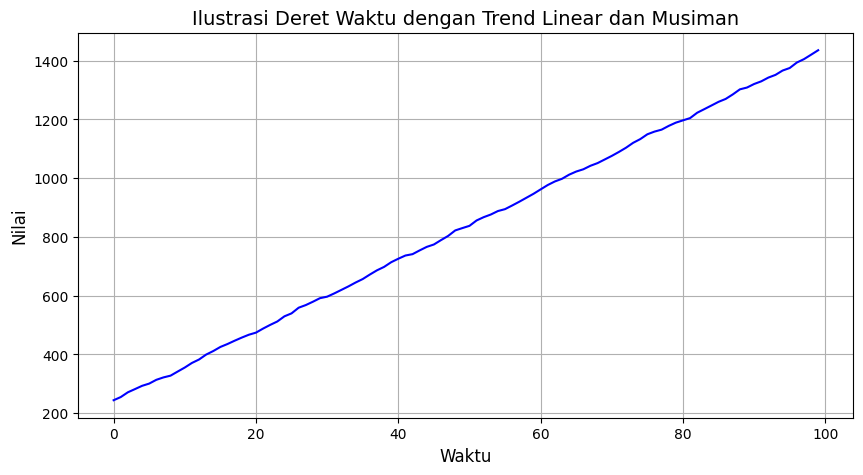

In [39]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

In [40]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [41]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [42]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.258e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          6.19e-190
Time:                        12:29:46   Log-Likelihood:                -209.30
No. Observations:                 100   AIC:                             444.6
Df Residuals:                      87   BIC:                             478.5
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari      241.5804      0.784    308.138      0.0

**Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?**

Berdasarkan hasil pengepasan model, koefisien setiap bulan menunjukkan adanya perbedaan nilai antarbulan yang menggambarkan pola musiman. Nilai koefisien period sebesar 12,0003 menunjukkan bahwa setiap bertambah satu periode, nilai pengamatan meningkat sekitar 12 satuan. Seluruh koefisien signifikan dengan p-value sebesar 0,000. Dengan demikian, model menunjukkan adanya pola musiman dan kecenderungan meningkat dari waktu ke waktu.

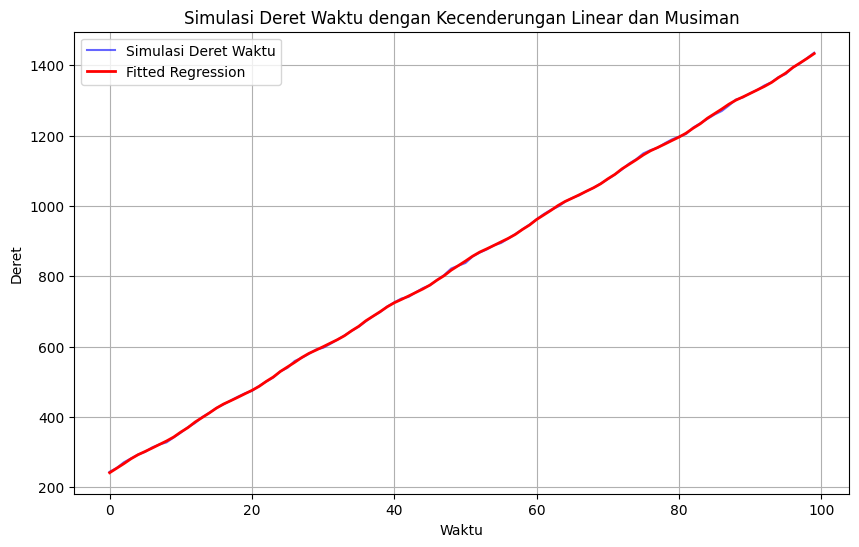

In [43]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!

In [44]:
# uji asumsi model

from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
import statsmodels.api as sm

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model_mix.resid, sm.add_constant(model_mix.model.exog))

print("P-value Breusch-Pagan Test:", round(bp_test[1], 4))

# Uji Ljung-Box
ljung_box_test = acorr_ljungbox(
    model_mix.resid,
    lags=range(1, 20),
    return_df=True
)

print("\nLjung-Box Test p-value:")
print(ljung_box_test)

# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model_mix.resid)

print("\nShapiro-Wilk Test:")
print("Statistics =", round(shapiro_stat, 4))
print("p-value =", round(shapiro_p_value, 4))

P-value Breusch-Pagan Test: 0.048

Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    1.602904   0.205492
2    1.643357   0.439693
3    1.682004   0.640942
4    1.832491   0.766533
5    1.856989   0.868558
6    6.084896   0.413748
7    7.852836   0.345749
8    7.919972   0.441326
9   10.204348   0.334197
10  13.391370   0.202605
11  14.718012   0.195774
12  18.629622   0.097867
13  18.835810   0.128283
14  19.373752   0.151154
15  21.717625   0.115425
16  21.996334   0.143310
17  22.358821   0.171310
18  22.587108   0.206959
19  22.752334   0.248427

Shapiro-Wilk Test:
Statistics = 0.9892
p-value = 0.5985


Model sudah memenuhi asumsi normalitas dan tidak terdapat autokorelasi, tetapi belum memenuhi asumsi homoskedastisitas karena hasil uji Breusch-Pagan menunjukkan adanya heteroskedastisitas.

Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

In [45]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

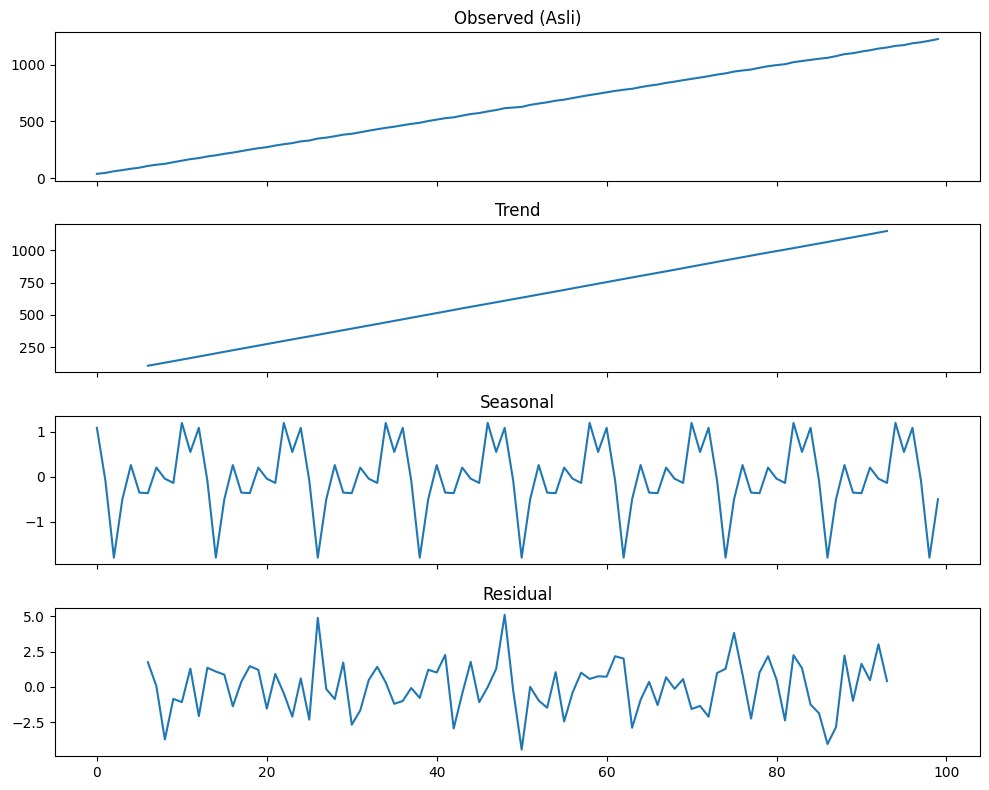

In [46]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

**Bagaimana interpretasi hasil dekomposisi deret tersebut?**

Berdasarkan hasil dekomposisi, deret tersebut terdiri dari tren, komponen musiman, dan residual (noise). Komponen tren menunjukkan pola yang terus meningkat secara hampir linear dari awal hingga akhir periode, sehingga terdapat kecenderungan kenaikan nilai dari waktu ke waktu. Komponen musiman menunjukkan pola yang berulang secara teratur pada setiap periode, meskipun besar pengaruhnya relatif kecil dibandingkan dengan tren. Sementara itu, komponen residual berfluktuasi di sekitar nilai nol dan tidak menunjukkan pola tertentu, sehingga bagian ini menggambarkan variasi acak yang tidak dijelaskan oleh tren dan musiman

In [47]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

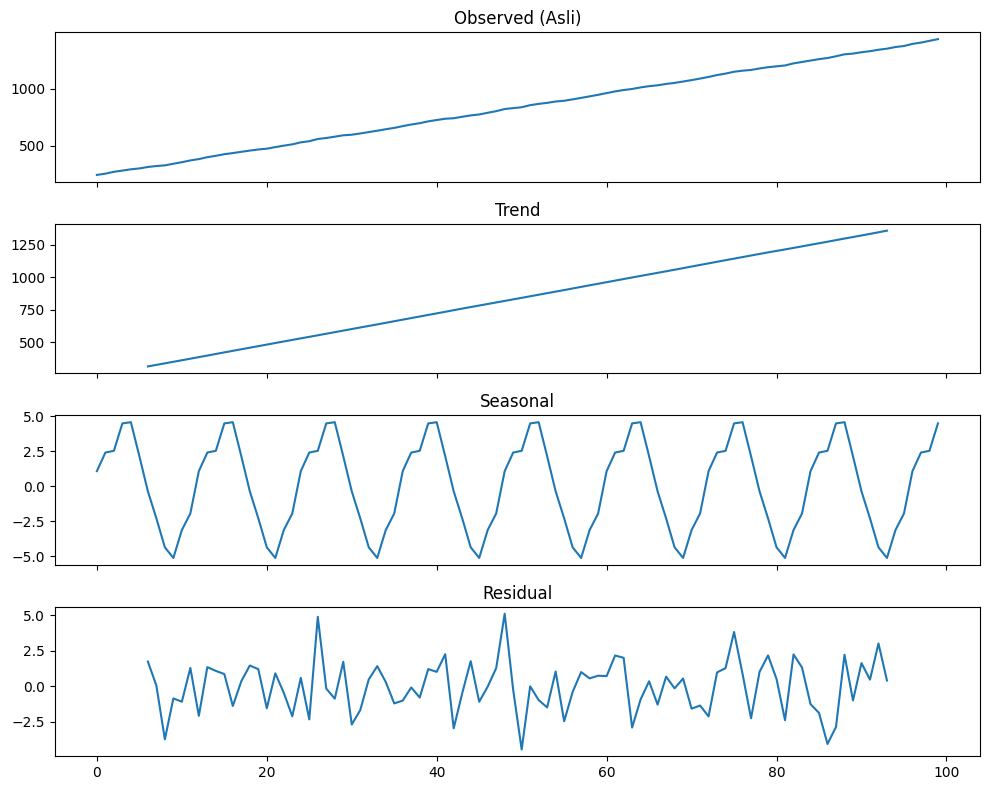

In [48]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


**Bagaimana interpretasi hasil dekomposisi deret tersebut?**

Berdasarkan hasil dekomposisi, deret tersebut memiliki tren yang meningkat secara linear dari awal hingga akhir periode. Komponen musiman terlihat jelas dan berulang secara teratur dengan pola yang hampir sama pada setiap periode, dengan nilai musiman berkisar sekitar -5 hingga 5. Sementara itu, residual berfluktuasi di sekitar nilai nol dan tidak menunjukkan pola tertentu. Jadi, deret tersebut dapat dikatakan terdiri dari tren linear, pola musiman yang cukup jelas, serta variasi acak (noise) pada residual.

Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [49]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(1024)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 1.2 , 240 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

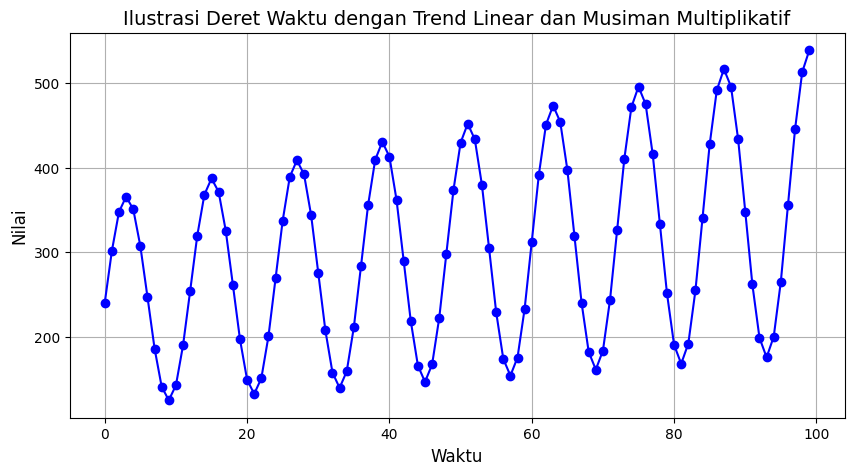

In [50]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

Berdasarkan grafik, deret menunjukkan tren yang terus meningkat dari waktu ke waktu. Selain itu, terlihat pola musiman yang berulang secara teratur, yaitu nilai naik hingga mencapai puncak kemudian turun kembali dan pola tersebut berulang. Besarnya fluktuasi musiman juga semakin besar ketika nilai deret meningkat. Hal ini menunjukkan bahwa pola musiman bergantung pada tingkat deret, sehingga deret tersebut sesuai dengan pola musiman multiplikatif.

Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.

In [51]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

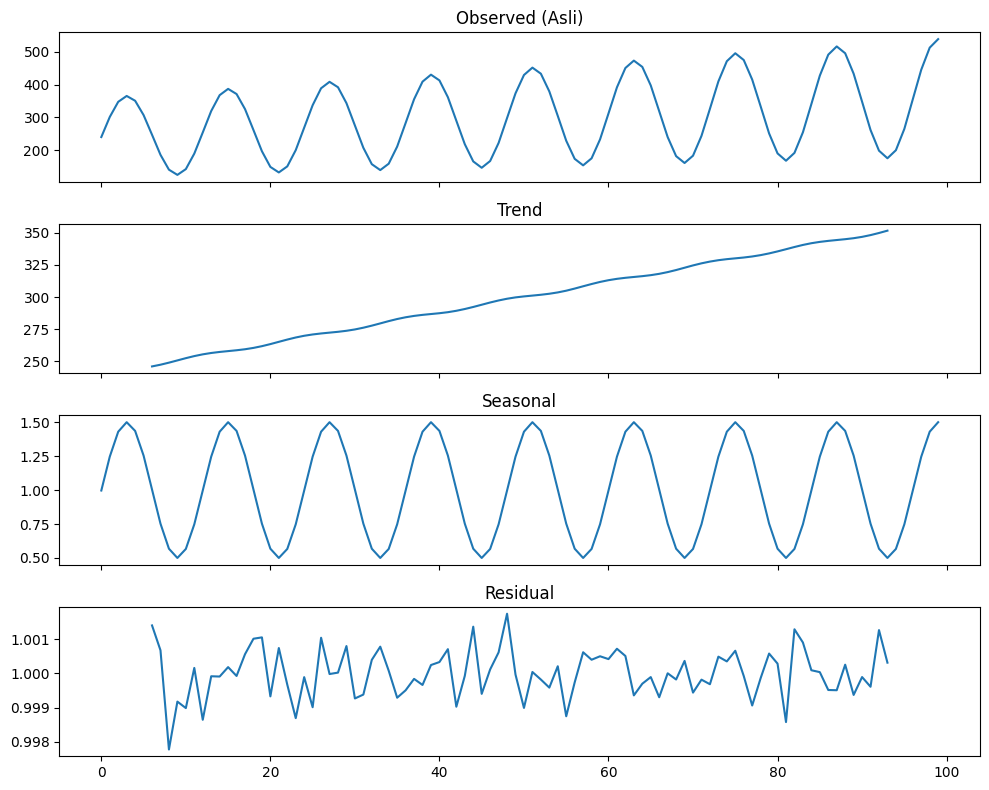

In [52]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

**Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?**

Berdasarkan hasil dekomposisi, deret memiliki tren yang meningkat dari waktu ke waktu. Komponen musiman menunjukkan pola yang berulang secara teratur pada setiap periode, dengan nilai musiman berkisar sekitar 0,5 hingga 1,5. Selain itu, besar fluktuasi pada deret asli semakin besar seiring meningkatnya nilai tren, sehingga pola ini menunjukkan adanya komponen musiman multiplikatif. Komponen residual berada di sekitar nilai 1 dan relatif kecil dibandingkan dengan deret asli, sehingga sebagian besar pola dalam deret sudah dapat dijelaskan oleh komponen tren dan musiman.

In [53]:
# Parameter
np.random.seed(1024)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

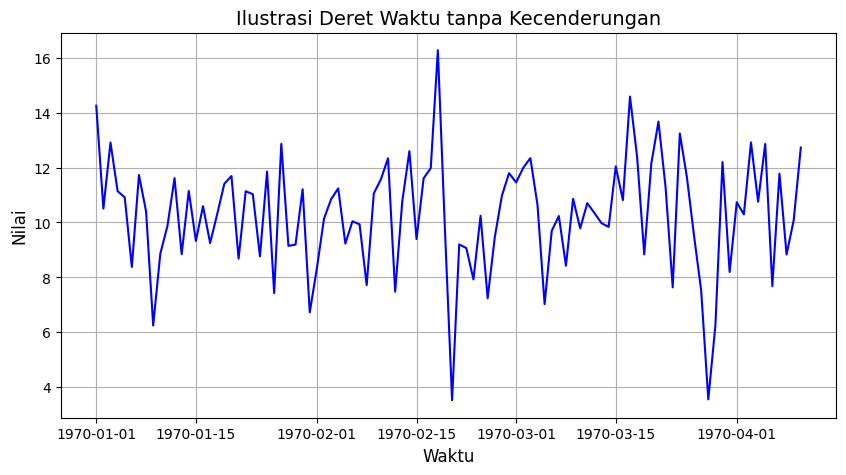

In [54]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

Plot menunjukkan bahwa deret tidak memiliki tren yang jelas. Nilai berfluktuasi di sekitar rata-rata 10–11 dan bergerak secara acak sepanjang waktu. Jadi, deret dapat dikatakan tidak memiliki komponen kecenderungan (tren).

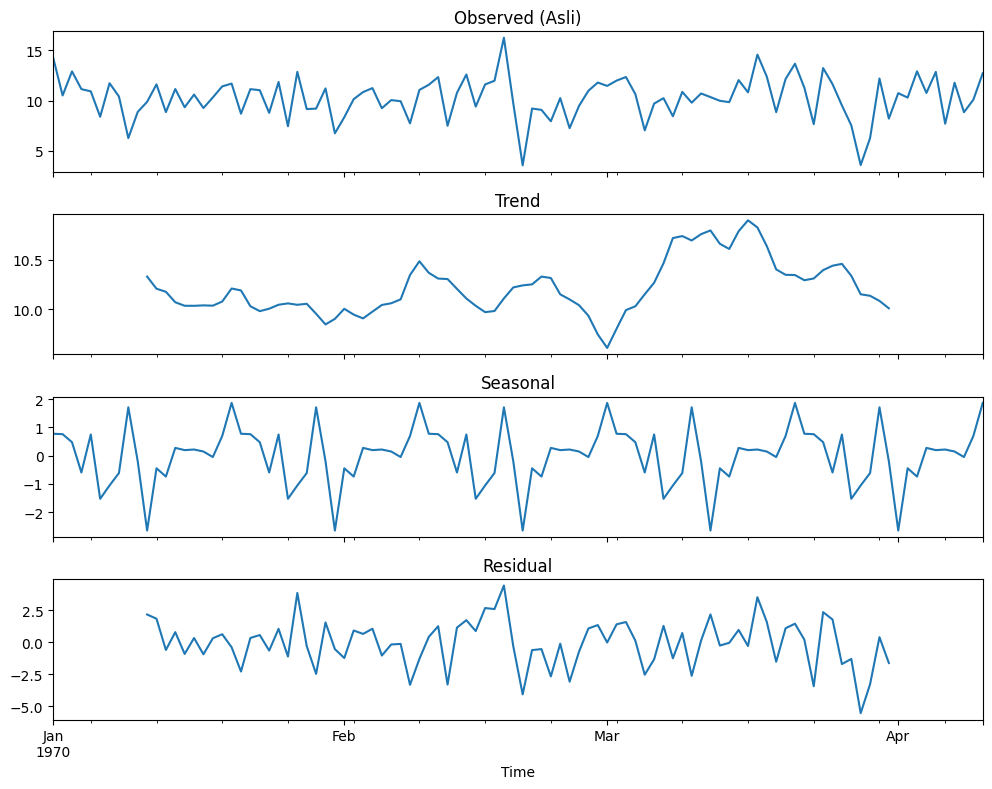

In [55]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

**Bagaimana interpretasi dari plot tersebut?**

Berdasarkan hasil dekomposisi, deret tersebut tidak menunjukkan tren yang kuat, karena komponen tren hanya berfluktuasi di sekitar nilai 10 dan tidak terus meningkat atau menurun. Komponen musiman terlihat jelas dan berulang secara teratur pada setiap periode, dengan pola yang relatif sama dari Januari hingga April. Sementara itu, komponen residual berfluktuasi di sekitar nilai nol dan tidak menunjukkan pola tertentu. Jadi, deret ini lebih banyak dipengaruhi oleh pola musiman dan variasi acak, sedangkan komponen trennya relatif kecil.